<a href="https://colab.research.google.com/github/prashantsingh05102006-sudo/ML_lab_24cd3033/blob/main/CNN_lab_part2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 11s 0us/step
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 391s 545ms/step - accuracy: 0.7492 - loss: 0.7226 - val_accuracy: 0.7816 - val_loss: 0.6152
Epoch 2/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 454s 562ms/step - accuracy: 0.8075 - loss: 0.5521 - val_accuracy: 0.7950 - val_loss: 0.5759
Epoch 3/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 428s 608ms/step - accuracy: 0.8274 - loss: 0.4909 - val_accuracy: 0.8058 - val_loss: 0.5552
Epoch 4/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 382s 543ms/step - accuracy: 0.8417 - loss: 0.4473 - val_accuracy: 0.8092 - val_loss: 0.5406
Epoch 5/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 386s 549ms/step - accuracy: 0.8567 - loss: 0.4042 - val_accuracy: 0.8128 - val_loss: 0.5495
Epoch 1/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 584s 811ms/step - accuracy: 0.7342 - loss: 0.8839 - val_accuracy: 0.7910 - val_loss: 0.6698
Epoch 2/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 632s 825ms/step - accuracy: 0.8080 - loss: 0.5670 - val_accuracy: 0.8110

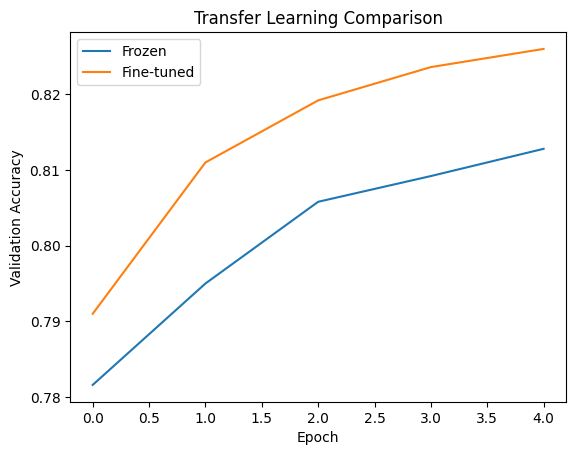

313/313 ━━━━━━━━━━━━━━━━━━━━ 69s 219ms/step - accuracy: 0.8260 - loss: 0.5563
Final Test Accuracy: 0.8259999752044678


In [1]:
# ===== TASK 5 =====

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical

# =========================
# 1. LOAD & PREPROCESS DATA
# =========================
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

X_train = tf.image.resize(X_train, (96,96)) / 255.0
X_test  = tf.image.resize(X_test, (96,96)) / 255.0

y_train = to_categorical(y_train, 10)
y_test  = to_categorical(y_test, 10)

# =========================
# 2. LOAD PRETRAINED MODEL (Problem 1)
# =========================
base_model = MobileNetV2(
    input_shape=(96,96,3),
    include_top=False,
    weights='imagenet'
)

# Freeze base model
base_model.trainable = False

# =========================
# 3. ADD CLASSIFICATION HEAD
# =========================
x = base_model.output
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dense(128, activation='relu')(x)
output = tf.keras.layers.Dense(10, activation='softmax')(x)

model = tf.keras.Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# =========================
# 4. TRAIN (Feature Extraction) – Problem 2
# =========================
history_frozen = model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

# =========================
# 5. FINE-TUNING – Problem 3
# =========================
# Unfreeze top layers
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_finetune = model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

# =========================
# 6. PLOTS (Problem 4)
# =========================
plt.plot(history_frozen.history['val_accuracy'], label='Frozen')
plt.plot(history_finetune.history['val_accuracy'], label='Fine-tuned')

plt.title("Transfer Learning Comparison")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()

plt.savefig("transfer_learning_comparison.png")
plt.show()

# =========================
# 7. FINAL TEST ACCURACY
# =========================
loss, acc = model.evaluate(X_test, y_test)
print("Final Test Accuracy:", acc)

Q1. Explain the concept of 'negative transfer'. Under what conditions might using ImageNet pre-trained
weights actually hurt performance rather than help? Give a concrete example of a domain where you would
expect negative transfer.

ANS=Negative transfer refers to a situation where using knowledge learned from one task or dataset actually harms the performance on a new task. In transfer learning, this happens when the features learned from the source dataset are not relevant or are misleading for the target dataset.

Using ImageNet pre-trained weights can hurt performance when the target data is very different from natural images. ImageNet models are trained on everyday objects like animals, vehicles, and scenes, so they learn features related to colors, textures, and shapes found in such images. If the new dataset has very different characteristics, these learned features may not be useful and can bias the model in the wrong direction.

Negative transfer is more likely to occur when there is a large domain mismatch, when the target dataset is very small, or when the task itself is very different from object classification.

A concrete example is medical imaging, such as MRI or X-ray scans. These images are usually grayscale and contain very different patterns compared to natural images. Using ImageNet pre-trained weights in this case may lead the model to focus on irrelevant features, reducing performance instead of improving it.

Q2. In your ablation (Problem 3), unfreezing all layers likely led to more overfitting than unfreezing only the
top few. Explain the bias-variance trade-off at play here. Why do the lower layers of a CNN trained on
ImageNet generalise better than the upper layers?

ANS=When all layers are unfrozen during fine-tuning, the model becomes highly flexible because a large number of parameters are updated. This increases the model’s ability to fit the training data very closely, which corresponds to low bias but high variance. As a result, the model may start overfitting, capturing noise and dataset-specific patterns instead of general features, leading to poorer performance on unseen data.

In contrast, when only the top few layers are unfrozen, most of the pretrained weights remain fixed. This limits the flexibility of the model, resulting in slightly higher bias but much lower variance. The model cannot overfit as easily and tends to generalize better on the test data.

The reason lower layers of a CNN generalize better is that they learn very basic and universal features such as edges, corners, and simple textures. These features are common across many types of images and are useful for a wide range of tasks. On the other hand, the upper layers learn more task-specific and high-level features, such as object parts or class-specific patterns from ImageNet. These features may not transfer well to a new dataset and can lead to overfitting if all layers are fine-tuned.

Q3. Your benchmark (Problem 4) compares parameter counts and accuracy across models. In a real
deployment scenario — e.g., a mobile app — what other factors beyond accuracy would influence your
choice of model? Name at least three and explain each.

ANS=In a real deployment scenario such as a mobile app, choosing a model depends on several factors beyond accuracy.

One important factor is inference time or latency. The model must make predictions quickly so that the app feels responsive to the user. A highly accurate model that takes too long to produce results may not be practical.

Another factor is memory and storage usage. Mobile devices have limited RAM and storage, so the model size should be small enough to fit and run efficiently without consuming too many resources.

A third factor is power consumption. Larger and more complex models require more computation, which can drain the device’s battery quickly. Efficient models are preferred to ensure longer battery life.

Additionally, model robustness and reliability are important. The model should perform consistently under different conditions such as varying lighting, noise, or input quality. This ensures a better user experience in real-world scenarios.

Q4. Suppose you have a completely new medical imaging dataset (X-ray scans, grayscale, 512×512) with
only 500 labelled training examples. Write a step-by-step transfer learning strategy you would follow,
justifying every choice (which base model, how many layers to freeze, learning rate, augmentation, etc.).

ANS=For a small medical imaging dataset like grayscale 512×512 X-ray scans with only 500 labelled examples, a careful transfer learning strategy is needed to avoid overfitting and make the most of limited data.

First, choose a strong pretrained model such as a ResNet or MobileNet trained on ImageNet. Even though ImageNet contains natural images, the lower layers of these models learn general features like edges and textures, which are still useful for medical images. Since X-ray images are grayscale, convert them to three channels by duplicating the single channel so they match the expected input format of the pretrained model.

Next, resize the images to a manageable size such as 224×224 or 256×256 to reduce computational cost while preserving important structure. Then apply data augmentation techniques like random rotations, flips, slight zoom, and contrast adjustments. This helps increase data diversity and reduces overfitting.

Initially, freeze most of the base model layers and only train a new classification head added on top. This allows the model to use pretrained features without overfitting quickly. Use a moderate learning rate such as 0.001 for training the new head.

After a few epochs, perform fine-tuning by unfreezing only the top few layers of the base model, keeping the lower layers frozen. This allows the model to adapt higher-level features to the medical domain. Use a very small learning rate such as 0.00001 during this stage to avoid destroying the pretrained weights.

Additionally, use regularization techniques such as dropout and early stopping to prevent overfitting. Monitor validation loss to decide when to stop training.

This step-by-step approach balances using pretrained knowledge and adapting to the new dataset, making it effective for small medical imaging problems.
